In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
print("ok")


ok


In [3]:
import joblib
model = joblib.load("fruad_model.pkl")
print("model loaded")

model loaded


In [4]:
preprocessor=joblib.load('fraud_preprocessor.pkl')

In [5]:
from langgraph.graph import START,END,StateGraph
from langchain_openai import ChatOpenAI
from typing import Literal,Annotated,TypedDict
from dotenv import load_dotenv
import pandas as pd
load_dotenv()

True

In [6]:
class fraudstate(TypedDict):
    claim:dict
    fraud:Literal["Yes","No"]
    fraud_probabaility:float
    top_features:dict
    explanation:str
    recommended_action:str


In [7]:
def predict_fraud_risk(claim:dict):
    claim_df=pd.DataFrame([claim])
    claim_transformed=preprocessor.transform(claim_df)
    predict=model.predict(claim_transformed)
    proba = model.predict_proba(claim_transformed)[0][1]
    if predict==0:
        predict='No'
    else:
        predict="Yes"
    return {"Fraud":predict,
        "fraud_probability": round(float(proba), 4)
    }
def get_top_features(n=5):
    importances = model.feature_importances_
    feature_names = preprocessor.get_feature_names_out()
    return pd.Series(importances, index=feature_names).sort_values(ascending=False).head(n).to_dict()

In [8]:
import json
with open("sample_claims.json") as f:
    sample_claims=json.load(f)

sample_claims[0]

{'Patient_Age': 48,
 'Patient_Gender': 'Female',
 'Diagnosis_Code': 'N39.0',
 'Procedure_Code': 99214,
 'Claim_Amount': 243.5,
 'Approved_Amount': 196.32,
 'Insurance_Type': 'Medicare',
 'Number_of_Claims_Per_Provider_Monthly': 71,
 'Provider_Specialty': 'Pulmonology',
 'Patient_State': 'TX',
 'Length_of_Stay': 5,
 'Visit_Type': 'Outpatient',
 'Chronic_Condition_Flag': 0,
 'Prior_Visits_12m': 1.0}

In [9]:
result=predict_fraud_risk(sample_claims[0])
result

{'Fraud': 'No', 'fraud_probability': 0.0005}

In [10]:
def predict_node(state:fraudstate):
    result=predict_fraud_risk(state['claim'])
    return {'fraud':result['Fraud'],'fraud_probabaility':result['fraud_probability']}

def explain_node(state:fraudstate):
    
    return {'top_features':get_top_features(n=5)}
    

In [11]:
llm=ChatOpenAI(model='gpt-4o-mini')


In [12]:
def reasoning_node(state:fraudstate):
    prompt=f"""
You are a health care paymenet-integrity assisstant.
Claim details: {state['claim']}
Model fraud probability: {state['fraud_probabaility']}
Top model features driving fraud predictions overall: {state['top_features']}

In 2-3 sentences, explain in plain English why this claim might be fraud or not fraud, referencing the claim's own values where relevant. Then give a recommended action: "Audit priority: High/Medium/Low" or "No action needed".
"""
    response=llm.invoke(prompt)
    return {'explanation':response.content}

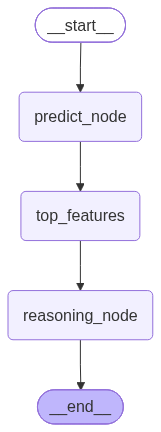

In [13]:
graph=StateGraph(fraudstate)
graph.add_node('predict_node',predict_node)
graph.add_node('top_features',explain_node)
graph.add_node('reasoning_node',reasoning_node)


graph.add_edge(START,'predict_node')
graph.add_edge('predict_node','top_features')
graph.add_edge('top_features','reasoning_node')
graph.add_edge('reasoning_node',END)

workflow=graph.compile()
workflow

In [20]:
sample=sample_claims[3]
sample

{'Patient_Age': 81,
 'Patient_Gender': 'Female',
 'Diagnosis_Code': 'E78.5',
 'Procedure_Code': 97110,
 'Claim_Amount': 318.95,
 'Approved_Amount': 289.6,
 'Insurance_Type': 'Medicare',
 'Number_of_Claims_Per_Provider_Monthly': 73,
 'Provider_Specialty': 'Unknown',
 'Patient_State': 'OH',
 'Length_of_Stay': 2,
 'Visit_Type': 'Outpatient',
 'Chronic_Condition_Flag': 0,
 'Prior_Visits_12m': 4.0}

In [21]:
result=workflow.invoke({'claim':sample})
print("Is Claim fraud :",result['fraud'])
print("Explanation: ",result['explanation'])

Is Claim fraud : No
Explanation:  This claim for an 81-year-old female patient has a low fraud probability of 0.0001, indicating that it is unlikely to be fraudulent. The approved amount is close to the claim amount, and there are no red flags related to the diagnosis or procedure codes. Given the patient's age and the treatment type, the claim appears reasonable. 

Recommended action: No action needed.
